In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../../scripts')

In [29]:
import numpy as np
import scanpy as sc
import os
DATA_ROOT = '/data2/a330d' #os.environ.get("DATA_ROOT", ".")
import matplotlib.pyplot as plt
import decoupler as dc
import scipy.sparse as sp
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from utils import set_seed
from train_loo import preprocess_crc, preprocess_merfish, _load_model, split_indices, preprocess_spatial_features
from counterfactual_analysis import compute_rmse, compute_edistance, mixing_index, get_lfc, precision, direction_match, compute_mse_lfc, _to_dense
from configs.adata_crc_holdout_config import ADATA_ARGS as ADATA_ARGS_CRC
from configs.adata_merfish_holdout_config import ADATA_ARGS as ADATA_ARGS_MERFISH
from configs.cellina_config import MODEL_ARGS as CELLINA_MODEL_ARGS, TRAIN_ARGS as CELLINA_TRAIN_ARGS, PLAN_KWARGS as CELLINA_PLAN_KWARGS
from configs.cellina_graph_config import MODEL_ARGS as CELLINA_GRAPH_MODEL_ARGS, TRAIN_ARGS as CELLINA_GRAPH_TRAIN_ARGS, PLAN_KWARGS as CELLINA_GRAPH_PLAN_KWARGS, N_NEIGHBORS_PER_SEED, N_NEIGHBORS_GRAPH


In [6]:
import cellina
import cellina_graph

cellina.__version__, cellina_graph.__version__

('0.7.4', '0.0.11')

In [7]:
set_seed(0)

In [8]:
DATASET_NAME = "crc"  # or "merfish"
MODEL_ROOT = os.path.join(DATA_ROOT, "data/ood/trained")

In [10]:
CRC_PATHS = [
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_120.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_210.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_221.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_231.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_242.h5ad"),
]

CRC_HOLDOUTS = [
    "Endothelial",
    "Epithelial",
    "Fibroblast",
    "Myeloid",
    "T_cell",
]

MERFISH_PATHS = [
    os.path.join(DATA_ROOT, "datasets/MERFISH_mouse_brain/C57BL6J-2.036.h5ad"),    
    os.path.join(DATA_ROOT, "datasets/MERFISH_mouse_brain/C57BL6J-2.039.h5ad"),
    os.path.join(DATA_ROOT, "datasets/MERFISH_mouse_brain/C57BL6J-2.041.h5ad"),
]

MERFISH_HOLDOUTS = [
    'glutamatergic neuron',
    'oligodendrocyte',
    'astrocyte',
    'GABAergic neuron',
    'endothelial cell',
]

PATHS = CRC_PATHS if DATASET_NAME == "crc" else MERFISH_PATHS
HOLDOUT_CELLTYPES = CRC_HOLDOUTS if DATASET_NAME == "crc" else MERFISH_HOLDOUTS
DATA_ARGS = ADATA_ARGS_CRC if DATASET_NAME == "crc" else ADATA_ARGS_MERFISH
COUNTS_PER_K = 1e4

In [11]:
n_top_genes = DATA_ARGS.get('n_top_genes')
labels_key = DATA_ARGS.get('labels_key')
domains_key = DATA_ARGS.get('domains_key')
batch_key = DATA_ARGS.get('batch_key')
control_domain = DATA_ARGS.get('control_domains')[0]
holdout_domains = DATA_ARGS.get('holdout_domains')
n_neighbors = DATA_ARGS.get('n_neighbors')
batch_size = 2048
library_size = 'latent'
n_deg = 50

In [ ]:
# Create SLIDES which contain file names from PATHS - first split by "/" and take last part, then split by "." and take first part
SLIDES = [path.split("/")[-1].split(".h5ad")[0] for path in PATHS]

## Training

In [ ]:
def train_ood_model(model_name, adata, splits, save_dir):
    if model_name == 'cellina':
        model_args = CELLINA_MODEL_ARGS.copy()
        train_args = CELLINA_TRAIN_ARGS.copy()
        plan_kwargs = CELLINA_PLAN_KWARGS.copy()

        import cellina
        from cellina import CellinaModel
        print("cellina version: ", cellina.__version__)
        CellinaModel.setup_anndata(adata, 
                                batch_key=batch_key, 
                                labels_key=labels_key, 
                                domains_key=domains_key, 
                                spatial_obsm_key='spatial_x', 
                                layer='counts')
        model = CellinaModel(adata, **model_args)

        # Add split info
        train_args['datasplitter_kwargs'] = {
                "external_indexing": [splits[0], splits[1], splits[2]],
                }
        if plan_kwargs is not None:
            model.train(**train_args, plan_kwargs=plan_kwargs)
        else:
            model.train(**train_args)
    elif model_name == 'cellina-graph':
        model_args = CELLINA_GRAPH_MODEL_ARGS.copy()
        train_args = CELLINA_GRAPH_TRAIN_ARGS.copy()
        plan_kwargs = CELLINA_GRAPH_PLAN_KWARGS.copy()
        
        from cellina_graph import CellinaModel
        CellinaModel.setup_anndata(adata, 
                                batch_key=batch_key, 
                                labels_key=labels_key, 
                                domains_key=domains_key, 
                                layer='counts',
                                spatial_connectivities_key='spatial_connectivities', 
                                )
        model = CellinaModel(adata, **model_args)
        print(model_args)

        # Add split info
        train_args['datasplitter_kwargs'] = {
                "external_indexing": [splits[0], splits[1], splits[2]],
                }
        if plan_kwargs is not None:
            model.train(**train_args, plan_kwargs=plan_kwargs)
        else:
            model.train(**train_args)
    else:
        raise ValueError(f"Unknown model_name: {model_name}. Supported: cellina, cellina-graph")
    
    # Save model
    model.save(save_dir, overwrite=True)

In [ ]:
train = True
inference = True
model_names = ['cellina-graph'] #['cellina']
results = []

for model_name in model_names:
    save_name = "cellina-ood" if model_name == 'cellina' else "cellina-gat-ood"
    model_class = "cellina" if model_name == 'cellina' else "cellina_graph"

    for path, slide_id in zip(PATHS, SLIDES):
        # 1. Data preprocessing
        adata = sc.read(path)
        if DATASET_NAME == 'crc':
            adata = preprocess_crc(adata, n_top_genes=n_top_genes, labels_key=labels_key, domains_key=domains_key)
        elif DATASET_NAME == 'merfish':
            adata = preprocess_merfish(adata, n_top_genes=n_top_genes, labels_key=labels_key, domains_key=domains_key)
        else:
            raise ValueError(f"Unknown dataset_name: {DATASET_NAME}. Supported: crc, merfish")

        # 50 times * in print
        print(f"{'='*50} Slide: {slide_id}{'='*50}")
        # create splits
        dummy_holdout_ct = 'Fibroblast' if DATASET_NAME == 'crc' else 'oligodendrocyte' # Dummy name for split indices, not actually used when holdout_full_domain=True
        train_idx, val_idx, test_idx = split_indices(adata,
                                                    holdout_celltype=dummy_holdout_ct,
                                                    labels_key=labels_key,
                                                    domains_key=domains_key,
                                                    holdout_domains=holdout_domains,
                                                    seed=0,
                                                    holdout_full_domain=True)

        splits = (train_idx, val_idx, test_idx)

        # Compute spatial features after splitting to avoid data leakage
        step_size_px = 0.12028 if DATASET_NAME == 'crc' else 0.109
        n_neighbors = N_NEIGHBORS_GRAPH if model_class=='cellina_graph' else DATA_ARGS.get('n_neighbors')
        adata = preprocess_spatial_features(adata, step_size_px=step_size_px, n_neighbors=n_neighbors, test_indices=test_idx)


        # 2. Train
        save_dir = os.path.join(MODEL_ROOT, slide_id, holdout_domains[0], model_name)
        if train:
            train_ood_model(model_name, adata, splits, save_dir)


        # 3. Inference
        if inference:
            try:
                model = _load_model(save_dir,
                                    model_class=model_class,
                                    adata=adata,
                                    splits=splits)
            except Exception as e:
                print(f"Failed to load model from {save_dir} with error: {e}")
                continue
            is_control_region = adata.obs[domains_key]==(control_domain)
            mask_control = is_control_region
            idx_control = np.where(mask_control.values)[0]  
            
            for hd in holdout_domains:
                for holdout_celltype in HOLDOUT_CELLTYPES:
                    print(f"{'='*50} Slide: {slide_id}, Holdout Celltype: {holdout_celltype} {'='*50}")
                    is_holdout_region = adata.obs[domains_key].astype(str) == hd
                    is_holdout_ct = adata.obs[labels_key].astype(str) == holdout_celltype
                    mask_target = is_holdout_region & is_holdout_ct
                    idx_target = np.where(mask_target.values)[0]

                    # "neighbour_indices" are indices of the neighbors of idx_target cells
                    conn = adata.obsp["spatial_connectivities_orig"]
                    sub_conn = conn[idx_target]                # rows for target cells
                    neighbor_indices = sub_conn.nonzero()[1]   # all neighbors at once
                    neighbor_indices = np.unique(neighbor_indices)
                    # remove neighbors having same ct as holdout_ct
                    neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

                    args_gex = {
                        "indices": idx_control,
                        "batch_size": batch_size,
                        "seed": 0,
                        "neighbour_indices": neighbor_indices
                    }
                    if model_class.lower() == 'cellina_graph':
                        args_gex["n_neighbors_per_seed"] = N_NEIGHBORS_PER_SEED
                    else:
                        args_gex['precomputed'] = False
                    
                    cf_counts = model.get_counterfactual_expression(**args_gex)
                    
                    # Compute stats
                    control = adata.layers['counts'][mask_control.values, :]
                    target = adata.layers['counts'][mask_target.values, :]
                    control, target = _to_dense(control), _to_dense(target)

                    counterfactual = cf_counts

                    gt_lfc, cf_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=n_deg)

                    spear, _ = spearmanr(gt_lfc[deg], cf_lfc[deg])
                    pear, _ = pearsonr(gt_lfc[deg], cf_lfc[deg])
                    prec = precision(gt_lfc, cf_lfc, k=n_deg, use_abs=True)
                    dir_match = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="intersection")
                    dir_match_k = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="k")
                    dir_match_gt = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="gt_topk")
                    mix_idx = mixing_index(observed=target, predicted=counterfactual, library_size=COUNTS_PER_K)
                    edist_global = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K)
                    edist_local = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True)
                    edist_pca_log = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True)
                    edist_pca = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True, log1p=False)
                    rmse = compute_rmse(observed=target, predicted=counterfactual, deg=deg, library_size=COUNTS_PER_K)
                    mse_lfc = compute_mse_lfc(gt_vec=gt_lfc, cf_vec=cf_lfc, deg=deg)

                    results.append(
                            dict(
                            dataset_name=DATASET_NAME,
                            sid=slide_id,
                            control_domain=control_domain,
                            target_domain=hd,
                            n_deg=n_deg,
                            model_name=save_name,
                            holdout_celltype=holdout_celltype,
                            spearman=spear,
                            pearson=pear,
                            precision=prec,
                            direction_match=dir_match,
                            direction_match_k=dir_match_k,
                            direction_match_gt=dir_match_gt,
                            mixing_index=mix_idx,
                            edistance_global=edist_global,
                            edistance_local=edist_local,
                            edistance_pca_log=edist_pca_log,
                            edistance_pca=edist_pca,
                            rmse=rmse,
                            mse_lfc=mse_lfc,
                            )
                    )

In [ ]:
results_csv_path = f'../../results/ood_cellina_{DATASET_NAME}_DEG_{n_deg}.csv'
df_results = pd.DataFrame(results)

# If file exists, append results to existing csv, otherwise create new csv
if os.path.exists(results_csv_path):
    df_results.to_csv(f"{results_csv_path}", index=False, mode='a', header=False)
else:
    df_results.to_csv(f"{results_csv_path}", index=False)

In [ ]:
# Take mean of metrics spearman, pearson, direction_match_k, edistance_pca_log
summary_df = df_results.groupby(['dataset_name', 'model_name', 'sid']).agg({
    'spearman': 'mean',
    'pearson': 'mean',
    'direction_match_k': 'mean',
    'edistance_pca_log': 'mean'
}).reset_index()
summary_df


# Compare results

In [23]:
cellina_df = pd.read_csv(f'../../results/ood_cellina_{DATASET_NAME}_DEG_{n_deg}.csv')
#mintflow_df = pd.read_csv(f'../../results/ood_mintflow_{DATASET_NAME}_DEG_{n_deg}.csv')
spatialprop_df = pd.read_csv(f'../../results/ood_spatialprop_{DATASET_NAME}_DEG_{n_deg}.csv')

In [24]:
for df in [cellina_df, spatialprop_df]:
    df['rmse'] = np.log10(df['rmse'])
    df['rmse_lfc'] = np.sqrt(df['mse_lfc'])

In [50]:
# Concat dataframe
combined_df = pd.concat([cellina_df, spatialprop_df], ignore_index=True)

In [51]:
# Rename model_names from dict
combined_df["model_name"] = combined_df["model_name"].map({
    "cellina-ood": "Cellina",
    "mintflow-ood": "MintFlow",
    "spatialprop-ood": "SpatialProp",
})

In [52]:
palette_dict = {
    'Cellina': '#8172B2',
    'MintFlow':    'green',
    'SpatialProp': 'skyblue',
}
palette = palette_dict

2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font fami

2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font family 'Arial' not found.
2026-06-05 10:49:21 | [WARNING] findfont: Font fami

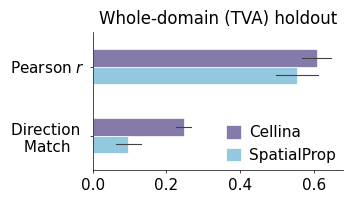

In [ ]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

metric_labels = {
    "pearson": r"Pearson $r$",
    "direction_match_k": "Direction \n Match   ",
}

metrics = list(metric_labels.keys())

df_long = (
    combined_df.melt(id_vars="model_name", value_vars=metrics, var_name="metric", value_name="value")
)
df_long["metric"] = df_long["metric"].map(metric_labels)

fig, ax = plt.subplots(figsize=(3.5, 2.0))

sns.barplot(
    data=df_long,
    y="metric",
    x="value",
    hue="model_name",
    palette=palette,
    orient="h",
    errorbar="se",
    err_kws={"linewidth": 0.8},
    width=0.5,
    ax=ax,
    linewidth=0.5,
    edgecolor="white",
)

sns.despine(ax=ax)

ax.set_xlabel("")
ax.set_ylabel("")
ax.legend(
    title="",
    loc="lower right",
    frameon=False,
)
ax.set_title('Whole-domain (TVA) holdout')

plt.tight_layout(pad=0.5)
plt.savefig("cellina_tva_metrics.svg", dpi=300, bbox_inches="tight")
plt.show()
